In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Data\data.csv")
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [4]:
df.isnull().sum().sort_values(ascending=False)

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

<Axes: >

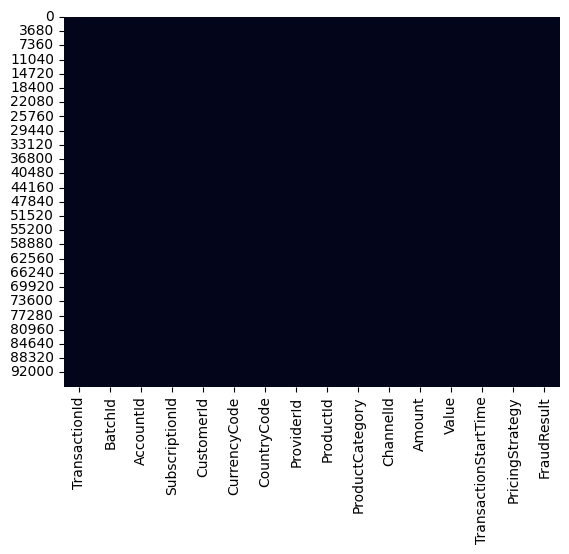

In [5]:
sns.heatmap(df.isnull(), cbar=False)

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df.columns:
    print(col)

TransactionId
BatchId
AccountId
SubscriptionId
CustomerId
CurrencyCode
CountryCode
ProviderId
ProductId
ProductCategory
ChannelId
Amount
Value
TransactionStartTime
PricingStrategy
FraudResult


In [9]:
df.columns.tolist()

['TransactionId',
 'BatchId',
 'AccountId',
 'SubscriptionId',
 'CustomerId',
 'CurrencyCode',
 'CountryCode',
 'ProviderId',
 'ProductId',
 'ProductCategory',
 'ChannelId',
 'Amount',
 'Value',
 'TransactionStartTime',
 'PricingStrategy',
 'FraudResult']

In [10]:
df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-30000.0,-5000.0,-50.0,1000.0,2800.0,14500.0,80000.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,10.0,25.0,275.0,1000.0,5000.0,25000.0,90000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,1.0,2.0,2.0,2.0,2.0,4.0,4.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [11]:
summary_stats = pd.DataFrame({
    'mean': df.mean(numeric_only=True),
    'median': df.median(numeric_only=True),
    'std': df.std(numeric_only=True),
    'min': df.min(numeric_only=True),
    'max': df.max(numeric_only=True),
    'skewness': df.skew(numeric_only=True),
    'kurtosis': df.kurtosis(numeric_only=True)
})

summary_stats

,mean,median,std,min,max,skewness,kurtosis
CountryCode,256.000000,256.0,0.000000,256.0,256.0,0.000000,0.000000
Amount,6717.846433,1000.0,123306.797164,-1000000.0,9880000.0,51.098490,3363.127739
Value,9900.583941,1000.0,123122.087776,2.0,9880000.0,51.291086,3378.069274
PricingStrategy,2.255974,2.0,0.732924,0.0,4.0,1.659057,2.087534
FraudResult,0.002018,0.0,0.044872,0.0,1.0,22.196295,490.685762


In [12]:
iqr = df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)
iqr.sort_values(ascending=False)

Value              4725.0
Amount             2850.0
CountryCode           0.0
PricingStrategy       0.0
FraudResult           0.0
dtype: float64

In [13]:
df.skew(numeric_only=True).sort_values()

CountryCode         0.000000
PricingStrategy     1.659057
FraudResult        22.196295
Amount             51.098490
Value              51.291086
dtype: float64

In [14]:
df.kurtosis(numeric_only=True).sort_values()

CountryCode           0.000000
PricingStrategy       2.087534
FraudResult         490.685762
Amount             3363.127739
Value              3378.069274
dtype: float64

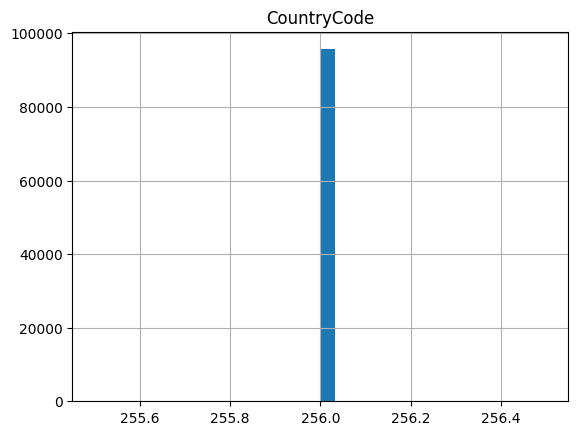

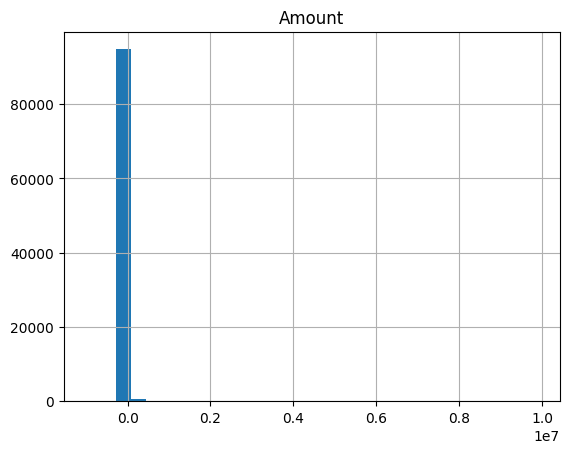

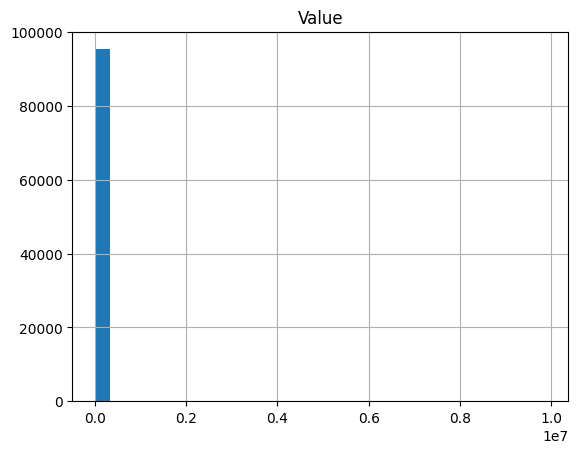

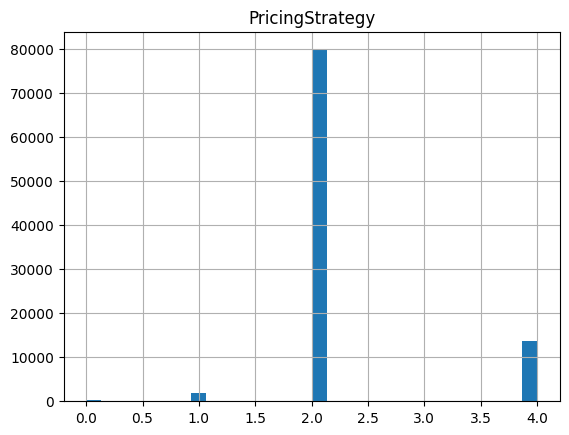

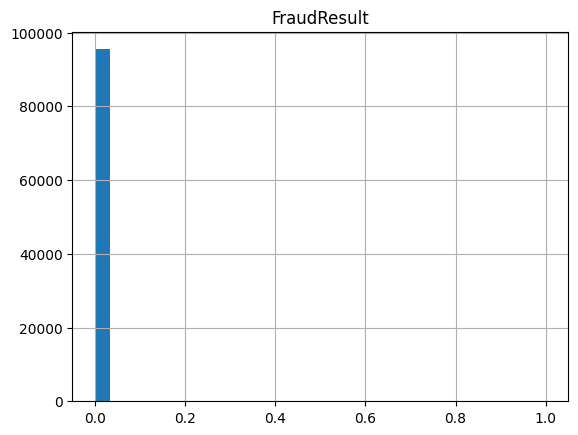

In [15]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(f"Number of numerical features: {len(num_cols)}")
num_cols

Number of numerical features: 5


Index(['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult'], dtype='str')

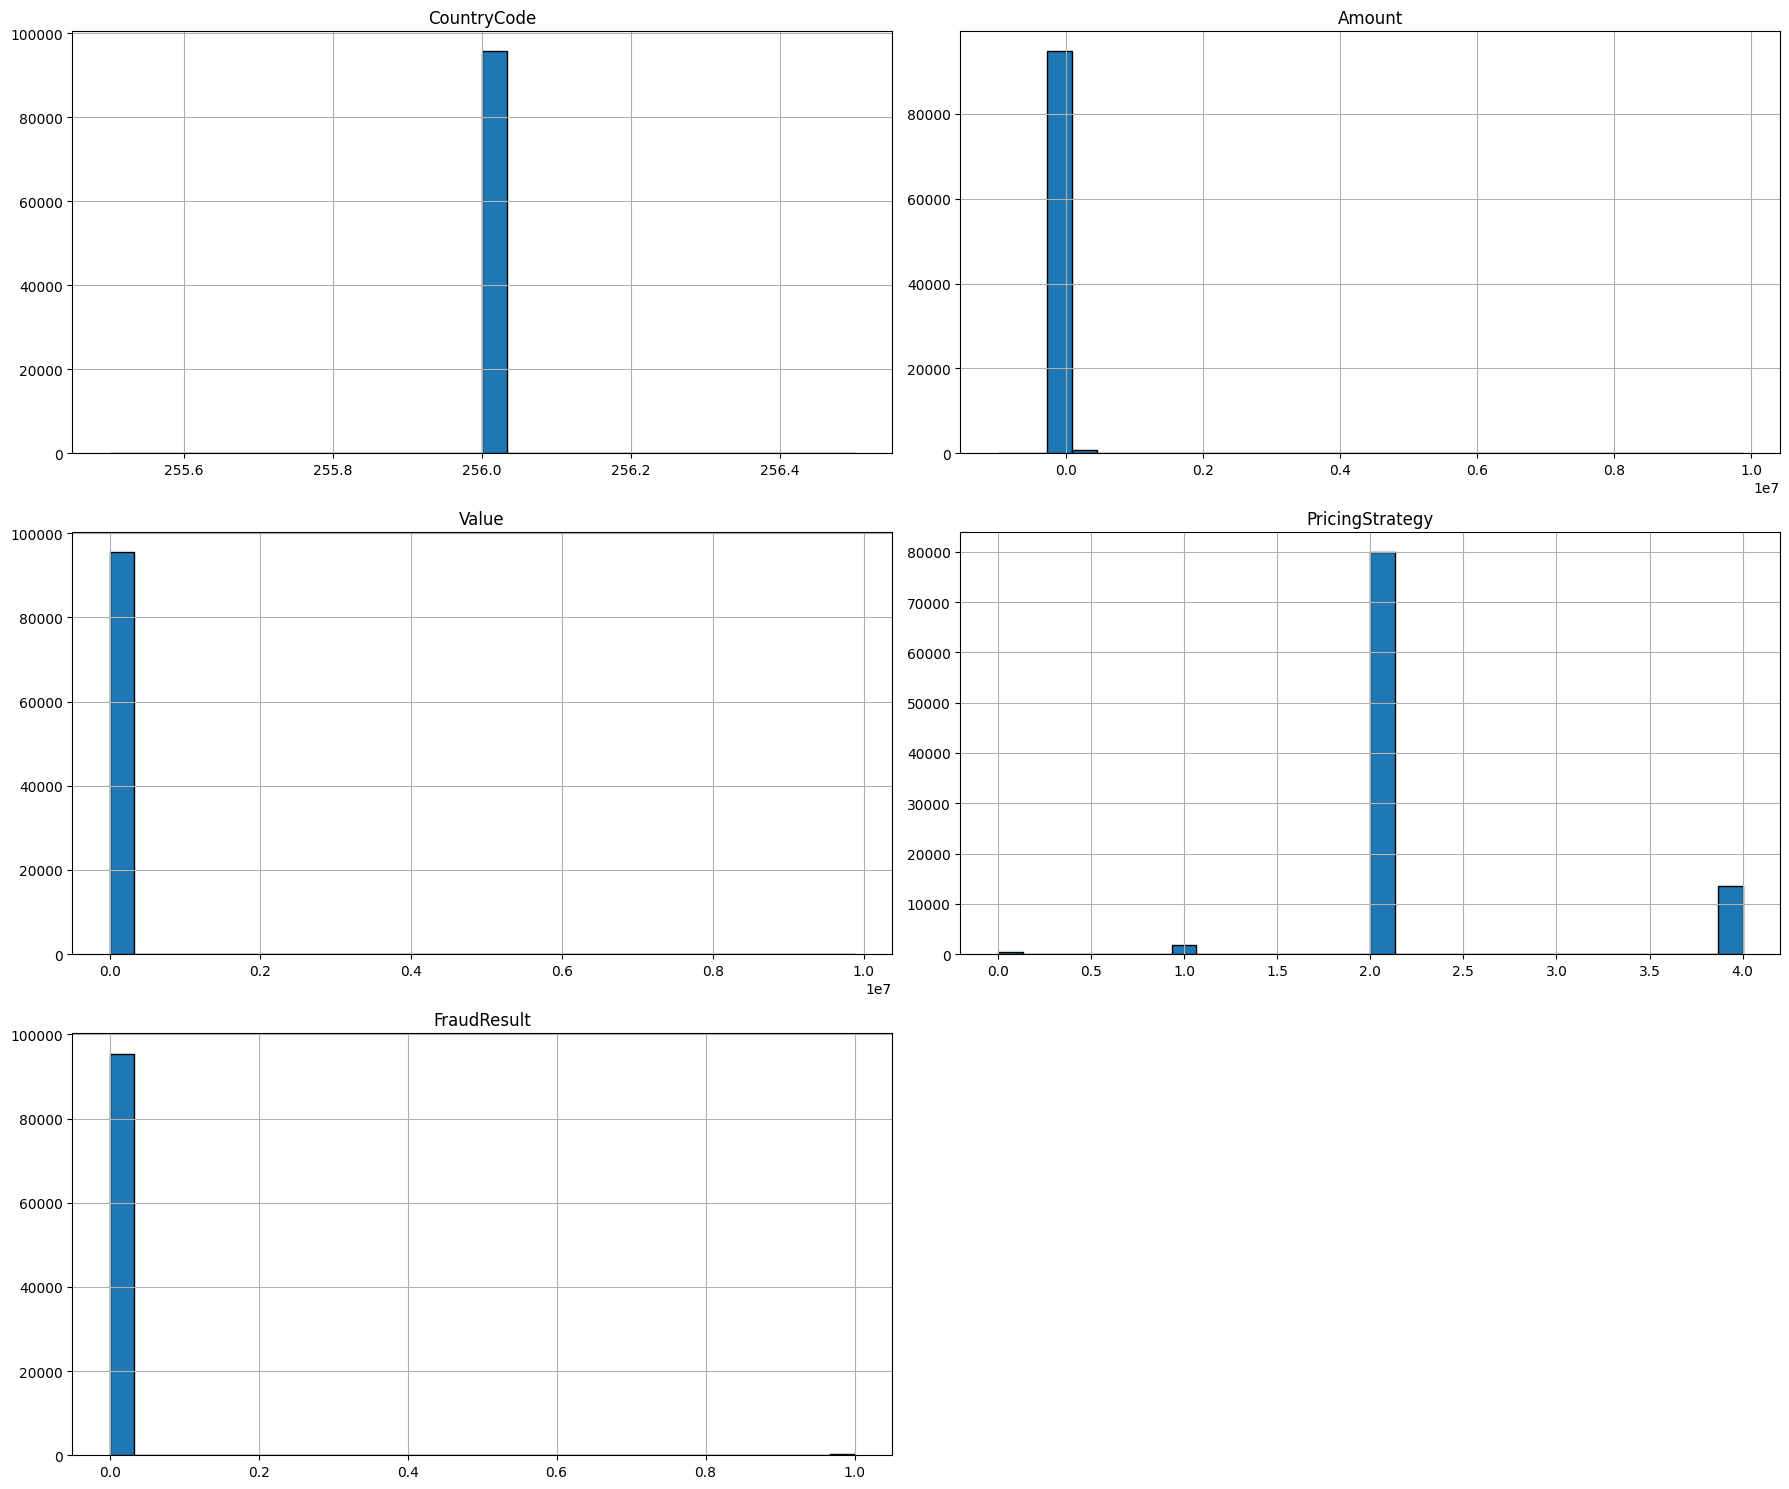

In [17]:
import matplotlib.pyplot as plt

df[num_cols].hist(
    bins=30,
    figsize=(18, 15),
    edgecolor='black'
)

plt.tight_layout()
plt.show()

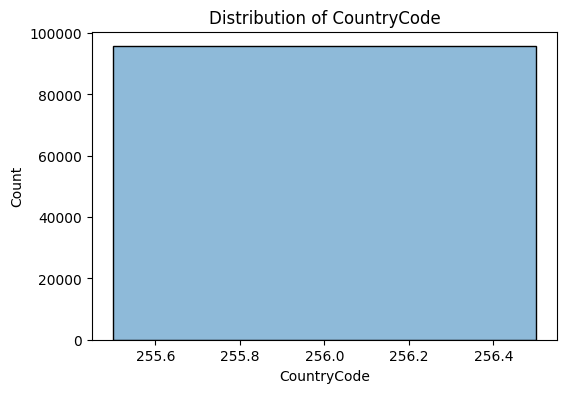

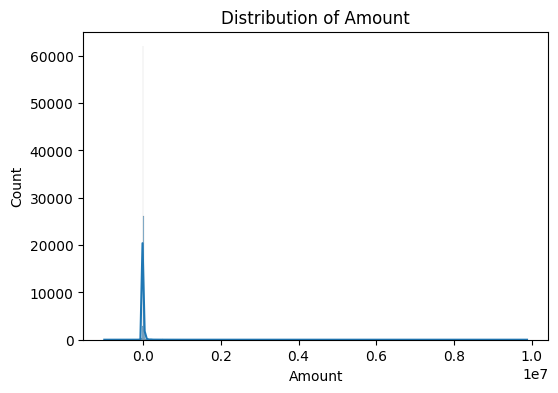

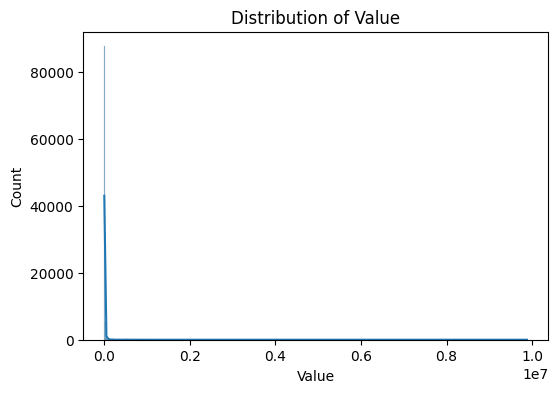

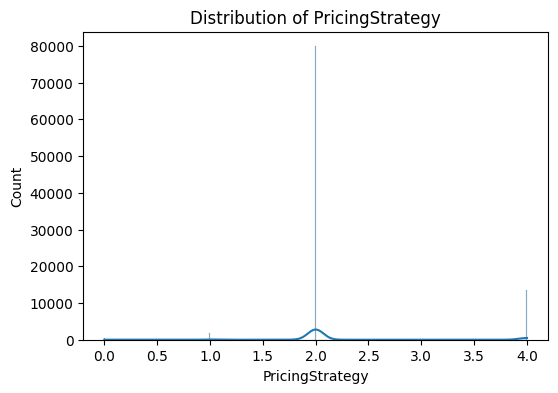

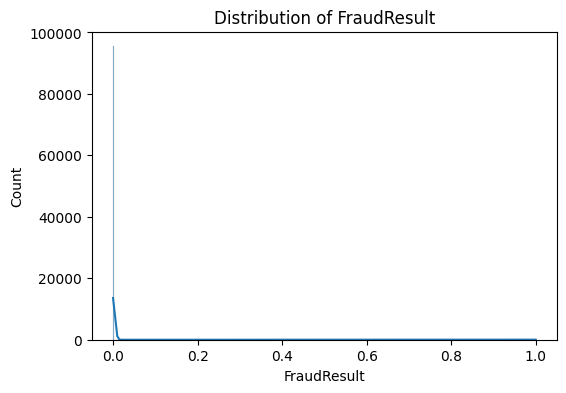

In [18]:
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

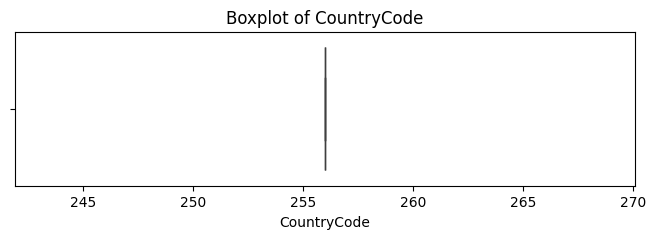

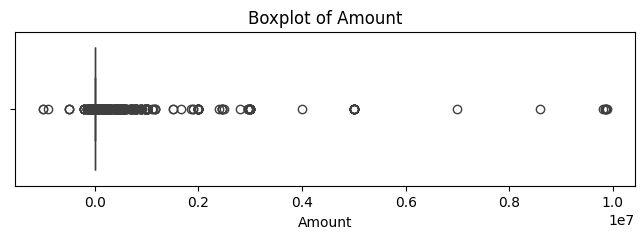

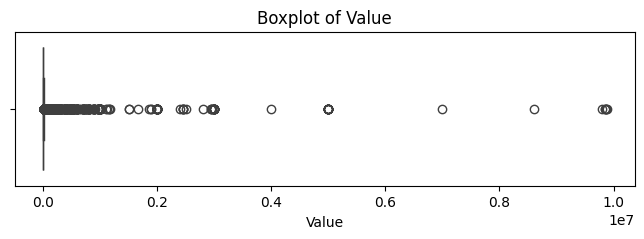

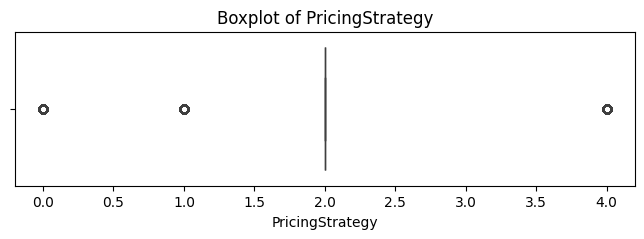

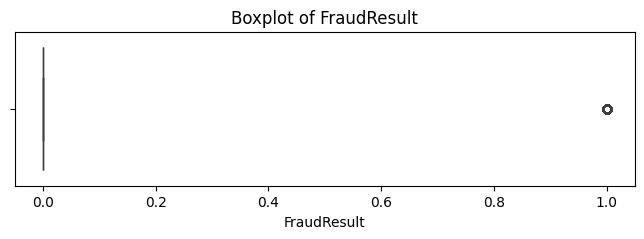

In [19]:
for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [20]:
skewness = df[num_cols].skew().sort_values(ascending=False)

skewness

Value              51.291086
Amount             51.098490
FraudResult        22.196295
PricingStrategy     1.659057
CountryCode         0.000000
dtype: float64

In [21]:
distribution_summary = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std": df[num_cols].std(),
    "skewness": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis()
})

distribution_summary.sort_values("skewness", ascending=False)

,mean,median,std,skewness,kurtosis
Value,9900.583941,1000.0,123122.087776,51.291086,3378.069274
Amount,6717.846433,1000.0,123306.797164,51.098490,3363.127739
FraudResult,0.002018,0.0,0.044872,22.196295,490.685762
PricingStrategy,2.255974,2.0,0.732924,1.659057,2.087534
CountryCode,256.000000,256.0,0.000000,0.000000,0.000000


In [22]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Number of categorical features: {len(cat_cols)}")
print(cat_cols.tolist())

Number of categorical features: 11
['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'TransactionStartTime']


C:\Users\Soret\AppData\Local\Temp\ipykernel_8400\7193017.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns


In [23]:
categorical_summary = pd.DataFrame({
    'unique_values': df[cat_cols].nunique(),
    'missing_values': df[cat_cols].isnull().sum()
})

categorical_summary.sort_values('unique_values', ascending=False)

,unique_values,missing_values
TransactionId,95662,0
BatchId,94809,0
TransactionStartTime,94556,0
CustomerId,3742,0
AccountId,3633,0
SubscriptionId,3627,0
ProductId,23,0
ProductCategory,9,0
ProviderId,6,0
ChannelId,4,0


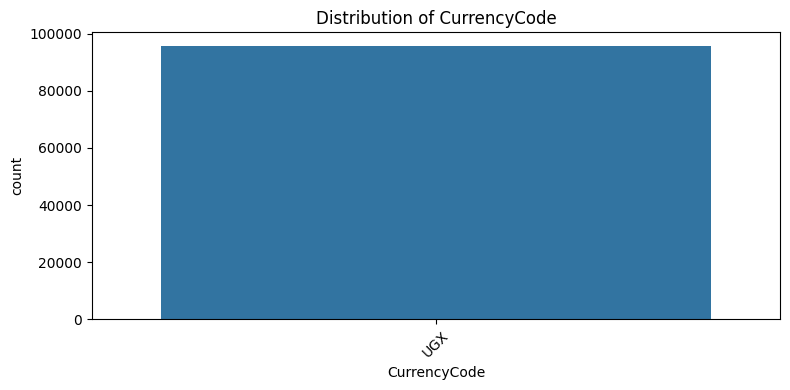

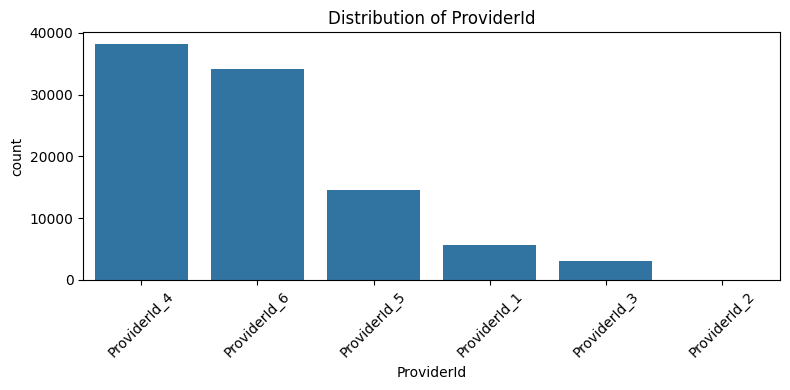

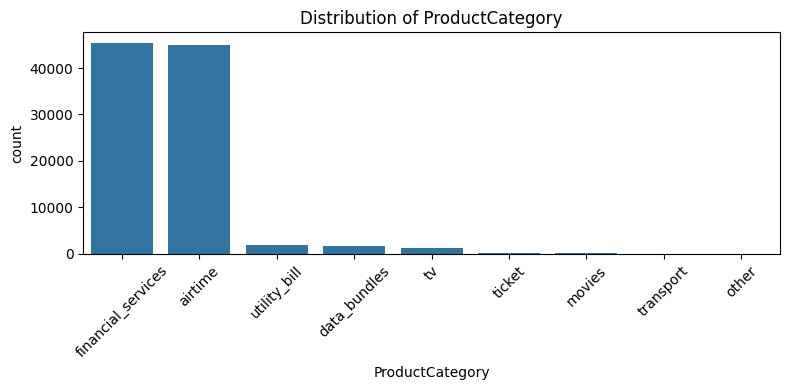

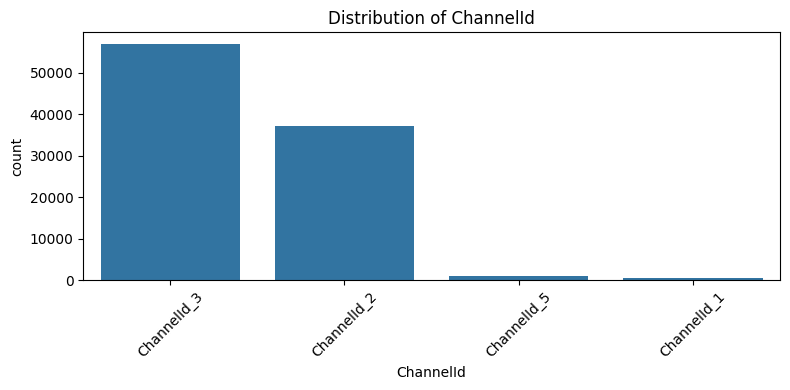

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(8,4))

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index
        )

        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [25]:
for col in cat_cols:
    print(f"\n{col}")
    print(
        (df[col].value_counts(normalize=True) * 100)
        .round(2)
        .astype(str) + '%'
    )


TransactionId
TransactionId
TransactionId_76871     0.0%
TransactionId_73770     0.0%
TransactionId_26203     0.0%
TransactionId_380       0.0%
TransactionId_28195     0.0%
                        ... 
TransactionId_89881     0.0%
TransactionId_91597     0.0%
TransactionId_82501     0.0%
TransactionId_136354    0.0%
TransactionId_35670     0.0%
Name: proportion, Length: 95662, dtype: str

BatchId
BatchId
BatchId_67019     0.03%
BatchId_51870     0.02%
BatchId_113893    0.01%
BatchId_127204    0.01%
BatchId_116835    0.01%
                  ...  
BatchId_96668      0.0%
BatchId_3503       0.0%
BatchId_118602     0.0%
BatchId_70924      0.0%
BatchId_29317      0.0%
Name: proportion, Length: 94809, dtype: str

AccountId
AccountId
AccountId_4841    32.29%
AccountId_4249     4.66%
AccountId_4840     1.82%
AccountId_3206     1.16%
AccountId_318      1.12%
                   ...  
AccountId_3524      0.0%
AccountId_2550      0.0%
AccountId_417       0.0%
AccountId_2476      0.0%
AccountId_16

In [26]:
for col in cat_cols:
    rare = df[col].value_counts(normalize=True)

    rare_categories = rare[rare < 0.01]

    if len(rare_categories) > 0:
        print(f"\nRare categories in {col}:")
        print(rare_categories)


Rare categories in TransactionId:
TransactionId
TransactionId_76871     0.00001
TransactionId_73770     0.00001
TransactionId_26203     0.00001
TransactionId_380       0.00001
TransactionId_28195     0.00001
                         ...   
TransactionId_89881     0.00001
TransactionId_91597     0.00001
TransactionId_82501     0.00001
TransactionId_136354    0.00001
TransactionId_35670     0.00001
Name: proportion, Length: 95662, dtype: float64

Rare categories in BatchId:
BatchId
BatchId_67019     0.000293
BatchId_51870     0.000167
BatchId_113893    0.000146
BatchId_127204    0.000125
BatchId_116835    0.000105
                    ...   
BatchId_96668     0.000010
BatchId_3503      0.000010
BatchId_118602    0.000010
BatchId_70924     0.000010
BatchId_29317     0.000010
Name: proportion, Length: 94809, dtype: float64

Rare categories in AccountId:
AccountId
AccountId_3595    0.004861
AccountId_751     0.004296
AccountId_2648    0.003753
AccountId_2314    0.003721
AccountId_1346    0.

In [27]:
df[col] = df[col].str.strip().str.lower()

In [28]:
corr_matrix = df[num_cols].corr()

corr_matrix

,CountryCode,Amount,Value,PricingStrategy,FraudResult
CountryCode,NaN,NaN,NaN,NaN,NaN
Amount,NaN,1.000000,0.989692,-0.061931,0.557370
Value,NaN,0.989692,1.000000,-0.017020,0.566739
PricingStrategy,NaN,-0.061931,-0.017020,1.000000,-0.033821
FraudResult,NaN,0.557370,0.566739,-0.033821,1.000000


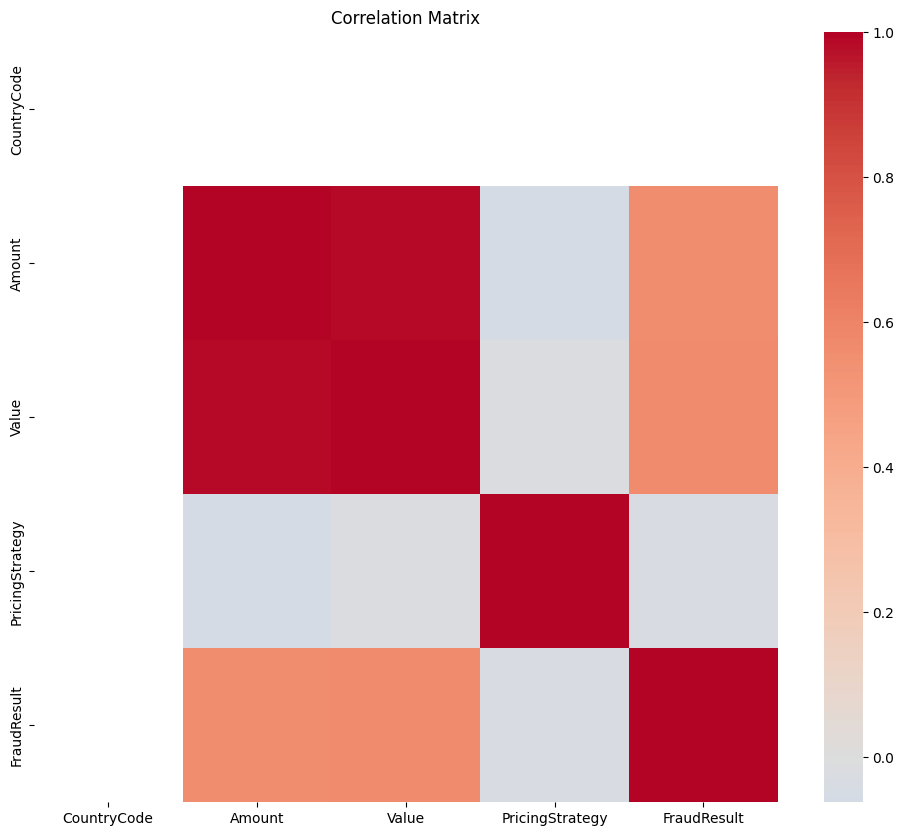

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

In [30]:
corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.head(20)

Value            Amount             0.989692
Amount           Value              0.989692
Value            FraudResult        0.566739
FraudResult      Value              0.566739
Amount           FraudResult        0.557370
FraudResult      Amount             0.557370
PricingStrategy  Amount             0.061931
Amount           PricingStrategy    0.061931
FraudResult      PricingStrategy    0.033821
PricingStrategy  FraudResult        0.033821
Value            PricingStrategy    0.017020
PricingStrategy  Value              0.017020
dtype: float64

In [31]:
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > 0.8:
            high_corr.append({
                "Feature_1": corr_matrix.columns[i],
                "Feature_2": corr_matrix.columns[j],
                "Correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr)

high_corr_df.sort_values(
    by="Correlation",
    key=abs,
    ascending=False
)

,Feature_1,Feature_2,Correlation
0,Value,Amount,0.989692


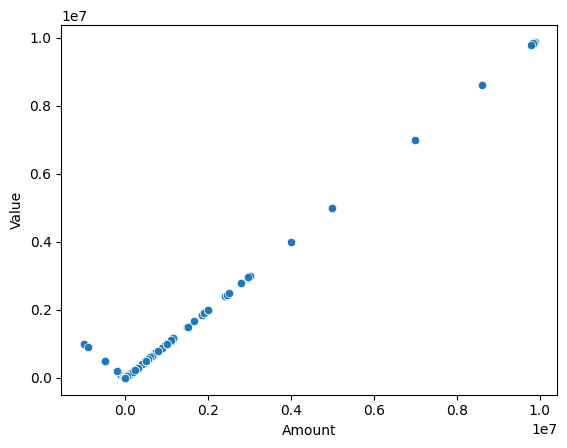

In [32]:
sns.scatterplot(
    data=df,
    x="Amount",
    y="Value"
)

plt.show()

In [34]:
missing_count = df.isnull().sum()

missing_count[missing_count > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [35]:
missing_percent = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage


In [38]:
if not missing_summary.empty:
    missing_summary["Missing Percentage"].plot(
        kind="bar",
        figsize=(12, 6)
    )
    plt.show()
else:
    print("No missing values found in the dataset.")

No missing values found in the dataset.


In [39]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]

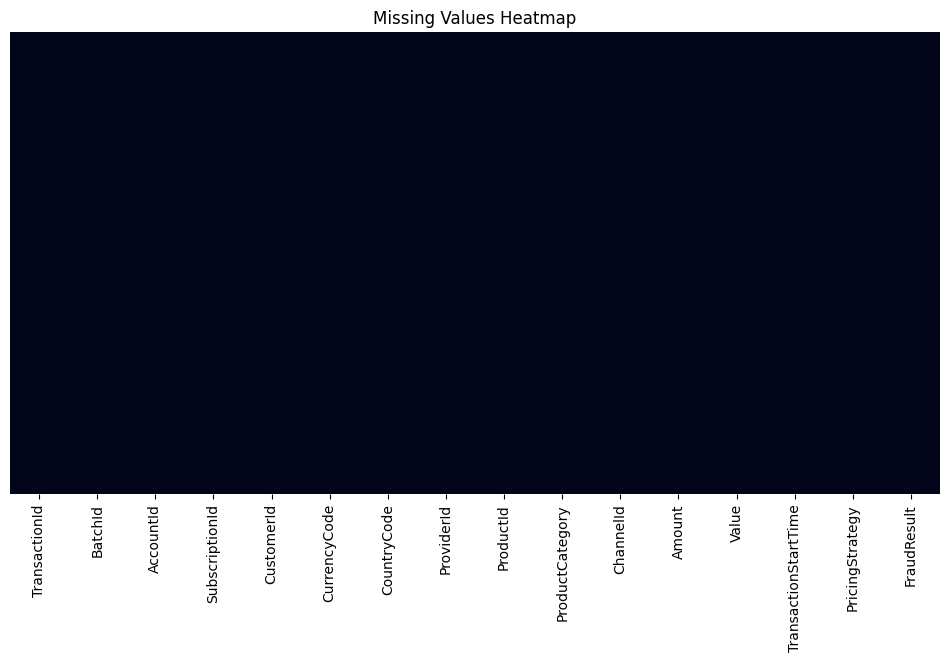

In [37]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

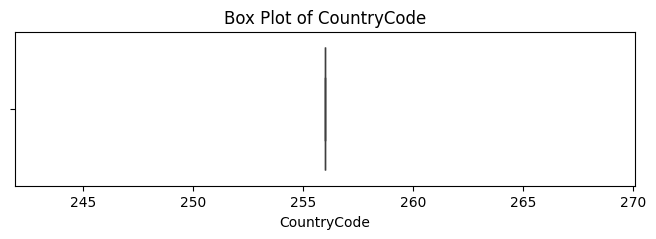

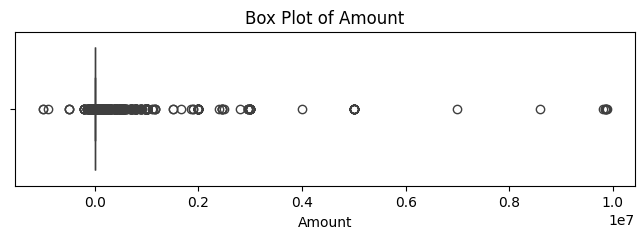

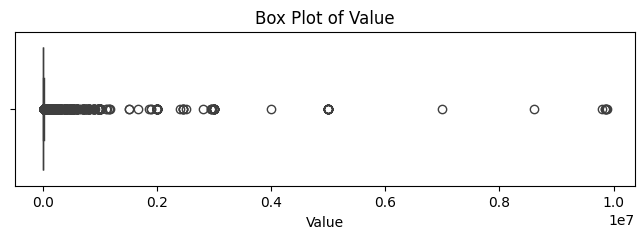

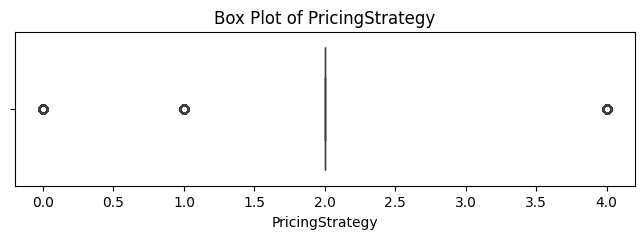

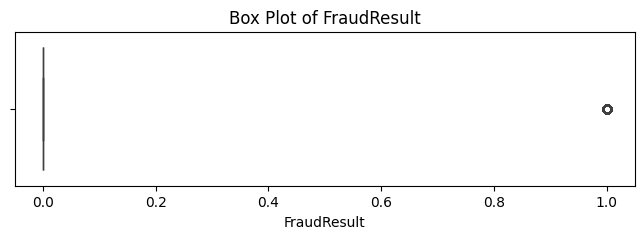

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(8, 2))

    sns.boxplot(x=df[col])

    plt.title(f'Box Plot of {col}')
    plt.show()

In [41]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(
            len(outliers) / len(df) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier Percentage",
    ascending=False
)

,Feature,Outlier Count,Outlier Percentage
1,Amount,24441,25.55
3,PricingStrategy,15814,16.53
2,Value,9021,9.43
4,FraudResult,193,0.20
0,CountryCode,0,0.00


In [42]:
outlier_summary[
    outlier_summary["Outlier Percentage"] > 5
]

,Feature,Outlier Count,Outlier Percentage
1,Amount,24441,25.55
2,Value,9021,9.43
3,PricingStrategy,15814,16.53
